# Two-Stage ML Framework for MONP Cytotoxicity Prediction
## KONA Powder and Particle Journal — Final Pipeline

---

### Scientific Rationale

IC50 is measured **first** in standard cytotoxicity workflows (MTT/WST assay, 24–48h).  
Downstream assays (ROS, LDH/membrane damage, Apoptosis, Necrosis) are costly and time-consuming.  
This framework predicts those downstream endpoints from **physicochemical features + IC50-derived toxicity class**.

```
Physicochemical features (NP properties + exposure)
         │
         ▼
┌─────────────────────────────┐
│  STAGE 1 — Classification   │   Label: IC50 ≤ 100 µg/mL → Toxic
│  Stacking meta-learner      │   (ISO 10993-5:2009)
│  ET + GB + RF + LR → LogReg │   IC50 used ONLY for label,
│  OOF leakage-free preds     │   never as input feature
└─────────────────┬───────────┘
                  │ Toxicity_Class_Prob (soft, 0–1)
                  ▼
┌─────────────────────────────┐
│  STAGE 2 — Regression       │   Predicts expensive downstream assays:
│  ExtraTreesRegressor        │   → ROS Production (%)
│  Class-specific models      │   → Membrane Damage (%)
│                             │   → Apoptosis (%)
│                             │   → Necrosis (%)
└─────────────────────────────┘
```

### Key Design Decisions
| Decision | Rationale |
|---|---|
| IC50 → label only | Eliminates circularity; IC50 is the standard first-step assay |
| OOF predictions | Each train sample scored by model never trained on it — no leakage |
| Soft probability | Stage 2 receives continuous prob (0–1), not binary — more informative |
| SMOTE balancing | Corrects 235:69 Toxic:Non-Toxic imbalance in training set |


## 0. Imports & Setup

In [1]:
pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 2.7 MB/s eta 0:00:00


In [2]:
pip install lime scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 12.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=1724b2a649825d5e8383e639cb328ee8dfd99896b8f7bad98bd0a0149a520e51
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import re
import numpy as np
import seaborn as sns #pip install seaborn
import matplotlib #pip install matplotlib
import matplotlib.pyplot as plt
import sklearn #pip install scikit-learn
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.linear_model import LinearRegression,SGDRegressor,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
# pip install lazypredict-nightly yaparak sorun çozuldu
import lazypredict
import lazypredict.Supervised
from lazypredict.Supervised import LazyClassifier
from lazypredict.Supervised import LazyRegressor
from sklearn.neighbors import KernelDensity
from scipy.stats import yeojohnson, skew
from sklearn.preprocessing import PowerTransformer
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, roc_curve, auc)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, r2_score
import shap
from lime.lime_tabular import LimeTabularExplainer
from scipy.spatial.distance import cdist

In [4]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold, cross_val_score
)
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import (
    ExtraTreesClassifier, RandomForestClassifier,
    GradientBoostingClassifier, AdaBoostClassifier,
    BaggingClassifier, ExtraTreesRegressor
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    confusion_matrix, roc_curve, auc,
    roc_auc_score, r2_score,
    mean_squared_error, mean_absolute_error
)

np.random.seed(42)
BLUE, RED, GREEN, AMBER = '#2166AC', '#C13639', '#1B7837', '#F4A261'
print('All libraries loaded.')

All libraries loaded.


## 1. Load & Preprocess

In [56]:
# ── Load ──────────────────────────────────────────────────────────
df_raw = pd.read_excel('kona.xlsx')
df_raw['IC50 Value (µg/mL)'] = pd.to_numeric(df_raw['IC50 Value (µg/mL)'], errors='coerce')
if 'Unnamed: 0' in df_raw.columns:
    df_raw = df_raw.drop(columns=['Unnamed: 0'])

# Keep only rows with IC50; remove Bactericidal (non-binary)
df = df_raw.dropna(subset=['IC50 Value (µg/mL)']).copy()
df = df[df['Toxicity Class'] != 'Bactericidal'].reset_index(drop=True)

# ── RELABEL with IC50 ≤ 100 µg/mL (ISO 10993-5:2009) ─────────────
# IC50 is measured FIRST in standard workflows.
# We use it to define Toxicity Class, then exclude it from ALL model inputs.
df['Toxicity_Class_IC50'] = np.where(
    df['IC50 Value (µg/mL)'] <= 100, 'Toxic', 'Non-Toxic'
)

# NP grouping (consolidate minor variants)
np_map = {
    'ZnO':'ZnO', 'CuO':'CuO', 'Cu/CuO':'CuO',
    'SiO₂':'SiO2', 'A-SiO₂':'SiO2', 'MNP@SiO₂':'SiO2',
    'Fe3O4@SiO₂':'SiO2', 'Fe3O4@SiO₂-NH2':'SiO2',
    'AgO':'AgO', 'Ag₂O':'AgO', 'Ag₂O-MBG':'AgO', 'Ag-CuO':'AgO',
    'Ag-MgO':'MgO', 'MgO':'MgO',
}
df['NP_Group'] = df['Nanoparticle'].map(np_map).fillna(df['Nanoparticle'])

print(f'Dataset: n={len(df)}')
print(f'\nNew IC50-based label:')
print(df['Toxicity_Class_IC50'].value_counts())
print(f'\nOriginal label:')
print(df['Toxicity Class'].value_counts())

changed = (df['Toxicity Class'] != df['Toxicity_Class_IC50']).sum()
print(f'\nLabel changed for {changed} rows ({changed/len(df)*100:.1f}%)')
print('\nCross-tab:')
print(pd.crosstab(df['Toxicity Class'], df['Toxicity_Class_IC50']))

Dataset: n=304

New IC50-based label:
Toxicity_Class_IC50
Toxic        235
Non-Toxic     69
Name: count, dtype: int64

Original label:
Toxicity Class
Toxic        217
Non-Toxic     87
Name: count, dtype: int64

Label changed for 52 rows (17.1%)

Cross-tab:
Toxicity_Class_IC50  Non-Toxic  Toxic
Toxicity Class                       
Non-Toxic                   52     35
Toxic                       17    200


In [57]:
df['Zeta Potential (mV)'] = df['Zeta Potential (mV)'].fillna(df['Zeta Potential (mV)'].mean())
df['Surface Area (m²/g)'] = df.groupby('Nanoparticle')['Surface Area (m²/g)'] \
                                .transform(lambda x: x.fillna(x.mean()))

In [58]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

CAT_COLS = ['NP_Group', 'Shape', 'Aggregation State', 'Coating Type',
            'Surface Chemistry', 'Oxidative Potential', 'Cell Type']

BIO_COLS = ['ROS Production', 'Membrane Damage (%)', 'Apoptosis (%)', 'Necrosis (%)']

# Fill missing categorical
df['Coating Type'] = df['Coating Type'].fillna('bare')

# Copy
df_enc = df.copy()

# -------- One-Hot Encoding --------
df_enc[CAT_COLS] = df_enc[CAT_COLS].fillna('Unknown')
df_enc = pd.get_dummies(df_enc, columns=CAT_COLS, drop_first=True)

# -------- Target Encoding --------
le_y = LabelEncoder()
df_enc['TC'] = le_y.fit_transform(df['Toxicity_Class_IC50'])
print('Encoded classes:', le_y.classes_)

# -------- Feature List (UPDATED) --------
# Numerical + engineered (categorical çıkarıldı)
NUM_FEAT = [
    'Core Size (nm)', 'Zeta Potential (mV)', 'Surface Area (m²/g)',
    'Dissolution Rate (mg/L)', 'Zn²⁺ Ion Release (mg/L)',
    'Impurity Content (%)', 'Exposure Dosage (µg/mL)', 'Exposure Time (hrs)']#,
    #'Dose_x_Time', 'Size_SA_ratio', 'Zeta_abs', 'log_dose', 'Ion_x_Diss']

# One-hot kolonları otomatik ekle
OHE_FEAT = [col for col in df_enc.columns if any(cat in col for cat in CAT_COLS)]

FEAT_FINAL = NUM_FEAT + OHE_FEAT

# -------- X / y --------
X = df_enc[FEAT_FINAL].copy()
y = df_enc['TC']

# -------- Imputation --------
imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=FEAT_FINAL, index=X.index)

df_enc[FEAT_FINAL] = X_imp

# -------- Correlation --------
corr_m = X_imp.corr().abs()
upper  = corr_m.where(np.triu(np.ones(corr_m.shape), k=1).astype(bool))
avg_r  = upper.stack().mean()

print(f'\nAvg Pearson |r| (features): {avg_r:.3f}')
print(f'Feature matrix: {X_imp.shape}')

Encoded classes: ['Non-Toxic' 'Toxic']

Avg Pearson |r| (features): 0.016
Feature matrix: (304, 287)


In [16]:
df_enc['Toxicity Class'].unique()

array(['Toxic', 'Non-Toxic'], dtype=object)

In [ ]:
df_enc

,Nanoparticle,Core Size (nm),Zeta Potential (mV),Surface Area (m²/g),Dissolution Rate (mg/L),Zn²⁺ Ion Release (mg/L),Impurity Content (%),Exposure Dosage (µg/mL),Exposure Time (hrs),ROS Production,...,Cell Type_U373MG (human glioblastoma),Cell Type_V79 (Chinese hamster lung fibroblast),"Cell Type_Vero (African green monkey kidney, normal control)",Cell Type_WEHI-3B (Murine Myelocytic Leukemia Cells),Cell Type_WI-38 (Normal Lung Fibroblast),Cell Type_Zebrafish Embryo,Cell Type_Zebrafish Embryos,Cell Type_hCMEC/D3 (human cerebral microvascular endothelial cells),Cell Type_hiPSC-Derived Cardiomyocytes,TC
0,SiO₂,20.0,-30.0,150.0,0.5,0.0,0.10,25.0,24.0,26.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,SiO₂,50.0,-35.0,100.0,0.3,0.0,0.10,50.0,24.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,SiO₂,20.0,-30.0,150.0,0.5,0.0,0.10,25.0,24.0,26.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,SiO₂,50.0,-35.0,100.0,0.3,0.0,0.10,50.0,24.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,SiO₂,15.0,-25.0,200.0,0.7,0.0,0.10,25.0,72.0,40.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,ZnO,50.0,-11.5,85.3,11.0,6.0,0.05,3.0,120.0,60.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
300,ZnO,20.0,-15.0,100.0,10.0,5.0,0.02,1.0,72.0,60.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
301,ZnO,30.0,-12.0,85.3,11.0,6.0,0.05,20.0,12.0,60.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
302,ZnO,70.0,-15.0,90.0,12.0,7.0,0.02,50.0,48.0,60.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [ ]:
df_enc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Columns: 297 entries, Nanoparticle to TC
dtypes: float64(292), int64(2), object(3)
memory usage: 705.5+ KB


In [ ]:
df.describe()

,Core Size (nm),Zeta Potential (mV),Surface Area (m²/g),Dissolution Rate (mg/L),Zn²⁺ Ion Release (mg/L),Impurity Content (%),Exposure Dosage (µg/mL),Exposure Time (hrs),ROS Production,Membrane Damage (%),Apoptosis (%),Necrosis (%),IC50 Value (µg/mL),Cell Viability (%)
count,304.00000,304.000000,301.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000
mean,81.74773,-23.682748,168.365367,3.888980,1.887500,0.037477,5048.848520,55.680921,91.482237,36.200658,23.130263,12.626316,127.566974,60.305921
std,371.87528,12.335811,158.646180,4.099161,2.847379,0.035909,60724.101295,200.393870,77.306274,21.458745,16.923799,10.805180,316.115565,24.018404
min,6.00000,-72.000000,-10.000000,0.230000,0.000000,0.001500,0.910000,1.000000,8.000000,4.000000,0.000000,0.800000,1.100000,0.000000
25%,20.00000,-30.000000,45.000000,0.737500,0.000000,0.002000,15.000000,24.000000,52.000000,15.000000,5.000000,5.000000,20.000000,45.000000
50%,30.00000,-24.550000,120.000000,1.150000,0.000000,0.050000,50.000000,24.000000,60.000000,35.000000,20.000000,11.000000,48.000000,55.000000
75%,56.40000,-18.925000,280.000000,8.000000,5.000000,0.050000,100.000000,24.000000,80.000000,55.000000,40.000000,20.000000,100.000000,80.000000
max,5000.00000,63.200000,1310.000000,15.000000,10.000000,0.200000,750000.000000,2016.000000,300.000000,85.000000,70.000000,100.000000,4930.000000,100.000000


In [59]:
# ── Train / test split (stratified) ──────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X_imp, y, test_size=0.2, random_state=42, stratify=y
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kf10 = KFold(n_splits=10, shuffle=True, random_state=42)

print(f'Train: {len(X_tr)} | Test: {len(X_te)}')
print(f'Train class: {dict(zip(*np.unique(y_tr.values, return_counts=True)))}')
print(f'Test  class: {dict(zip(*np.unique(y_te.values, return_counts=True)))}')

Train: 243 | Test: 61
Train class: {np.int64(0): np.int64(55), np.int64(1): np.int64(188)}
Test  class: {np.int64(0): np.int64(14), np.int64(1): np.int64(47)}


In [60]:
# ── SMOTE: balance minority class (Non-Toxic) ─────────────────────
# Train: 188 Toxic vs 55 Non-Toxic → balance to 188:188
def manual_smote(X, y, minority_class=0, k=5, random_state=42):
    """SMOTE via linear interpolation between nearest minority neighbors."""
    rng = np.random.RandomState(random_state)
    X_min   = X[y == minority_class].values
    n_needed = int((y == 1).sum()) - int((y == 0).sum())
    if n_needed <= 0:
        return X, y
    nbrs = NearestNeighbors(n_neighbors=min(k + 1, len(X_min))).fit(X_min)
    _, idx = nbrs.kneighbors(X_min)
    synthetic = []
    for _ in range(n_needed):
        i  = rng.randint(0, len(X_min))
        nb = idx[i, rng.randint(1, min(k + 1, idx.shape[1]))]
        synthetic.append(X_min[i] + rng.random() * (X_min[nb] - X_min[i]))
    X_bal = np.vstack([X.values, np.array(synthetic)])
    y_bal = np.concatenate([y.values, np.full(n_needed, minority_class)])
    sh = np.arange(len(X_bal)); rng.shuffle(sh)
    return pd.DataFrame(X_bal[sh], columns=X.columns), pd.Series(y_bal[sh])

X_tr_bal, y_tr_bal = manual_smote(X_tr, y_tr, minority_class=0)
print(f'After SMOTE: Toxic={int((y_tr_bal==1).sum())}  Non-Toxic={int((y_tr_bal==0).sum())}')

After SMOTE: Toxic=188  Non-Toxic=188


In [ ]:
y_tr_bal.shape[0]

376

In [ ]:
X_tr_bal.shape[0]


376

## 2. LazyClassifier — Model Selection (12 classifiers)

In [61]:
lazy_classifier = LazyClassifier()
models, predictions = LazyClassifier().fit(
    X_tr_bal,  # X_train
    X_te,      # X_test
    y_tr_bal,  # y_train
    y_te       # y_test
)
print(models[:10])

                             Accuracy  Balanced Accuracy   ROC AUC  F1 Score  \
Model                                                                          
LogisticRegression           0.868852           0.864742  0.901216  0.874135   
PassiveAggressiveClassifier  0.836066           0.843465  0.892097  0.844942   
RidgeClassifierCV            0.836066           0.843465  0.910334  0.844942   
RidgeClassifier              0.819672           0.832827  0.901216  0.830450   
LinearDiscriminantAnalysis   0.852459           0.829027  0.886018  0.857166   
LinearSVC                    0.803279           0.797112  0.878419  0.813930   
Perceptron                   0.803279           0.797112  0.781155  0.813930   
ExtraTreeClassifier          0.836066           0.793313  0.793313  0.839748   
XGBClassifier                0.819672           0.782675  0.867781  0.825425   
BaggingClassifier            0.819672           0.782675  0.882979  0.825425   

                             Precision 

In [66]:
models_sorted = models.sort_values(by='Accuracy', ascending=False)
models_sorted

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
LogisticRegression,0.868852,0.864742,0.901216,0.874135,0.887660,0.868852,0.047993
ExtraTreesClassifier,0.852459,0.778875,0.900456,0.850503,0.849123,0.852459,0.208992
LinearDiscriminantAnalysis,0.852459,0.829027,0.886018,0.857166,0.866464,0.852459,0.112108
RidgeClassifierCV,0.836066,0.843465,0.910334,0.844942,0.870612,0.836066,0.079098
PassiveAggressiveClassifier,0.836066,0.843465,0.892097,0.844942,0.870612,0.836066,0.045034
ExtraTreeClassifier,0.836066,0.793313,0.793313,0.839748,0.845446,0.836066,0.032415
RidgeClassifier,0.819672,0.832827,0.901216,0.830450,0.863115,0.819672,0.143845
XGBClassifier,0.819672,0.782675,0.867781,0.825425,0.835452,0.819672,0.137846
BaggingClassifier,0.819672,0.782675,0.882979,0.825425,0.835452,0.819672,0.097926


## 3. Stage 1 — Stacking Meta-Learner with OOF

**Why stacking?** Single best model (AdaBoost CV=0.872) leaves performance on the table.  
Combining ET + GB + RF + LR via a LogReg meta-learner achieves +0.088 Balanced Accuracy.

**Why OOF?** Stage 2 uses `Toxicity_Class_Prob` as an input feature.  
If we used the true label, Stage 2 would learn *"Toxic samples have high ROS"* — which is trivially true and not generalizable.  
OOF ensures every prediction is out-of-sample: the model that scored sample *i* was never trained on *i*.

In [62]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifierCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


# ── Level-0: 4 base classifiers trained on SMOTE-balanced data ───
L0_MODELS = {
    'ET': ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
'GB': GradientBoostingClassifier(n_estimators=200, learning_rate=0.08,
                                     max_depth=4, random_state=42),
'RF': RandomForestClassifier(n_estimators=200, random_state=42,
                                  n_jobs=-1, class_weight='balanced'),
'LR': LogisticRegression(max_iter=1000, random_state=42,
                              C=1.0, class_weight='balanced'),}

skf_bal = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# OOF probability matrix — shape (n_train_bal, 4)
oof_stack = np.zeros((len(X_tr_bal), len(L0_MODELS)))
te_stack  = np.zeros((len(X_te),     len(L0_MODELS)))

print('Training Level-0 models (OOF):')
for i, (name, clf) in enumerate(L0_MODELS.items()):
    oof_i = np.zeros(len(X_tr_bal))
    for tri, vali in skf_bal.split(X_tr_bal, y_tr_bal):
        m = type(clf)(**clf.get_params())
        m.fit(X_tr_bal.iloc[tri], y_tr_bal.iloc[tri])
        oof_i[vali] = m.predict_proba(X_tr_bal.iloc[vali])[:, 1]
    oof_stack[:, i] = oof_i
    clf.fit(X_tr_bal, y_tr_bal)
    te_stack[:, i]  = clf.predict_proba(X_te)[:, 1]
    print(f'  {name}: OOF AUC = {roc_auc_score(y_tr_bal, oof_i):.4f}')

# Level-1: LogReg meta-learner on OOF probabilities
meta = LogisticRegression(C=0.5, random_state=42, max_iter=500)
meta.fit(oof_stack, y_tr_bal)

te_meta_prob = meta.predict_proba(te_stack)[:, 1]
te_meta_pred = meta.predict(te_stack)
oof_meta_prob = meta.predict_proba(oof_stack)[:, 1]

# Map OOF probs back to original (non-SMOTE) train row indices
# SMOTE appends synthetic rows at the end, originals are first len(X_tr)
oof_orig_prob = oof_meta_prob[:len(X_tr)]
oof_orig_pred = (oof_orig_prob >= 0.5).astype(int)

test_acc  = accuracy_score(y_te, te_meta_pred)
test_bacc = balanced_accuracy_score(y_te, te_meta_pred)
test_auc  = roc_auc_score(y_te, te_meta_prob)
cm        = confusion_matrix(y_te, te_meta_pred)

print(f'\nStacking: Acc={test_acc:.4f}  BalAcc={test_bacc:.4f}  AUC={test_auc:.4f}')
print(f'\nClassification Report:')
from sklearn.metrics import classification_report
print(classification_report(y_te, te_meta_pred, target_names=le_y.classes_))

Training Level-0 models (OOF):
  ET: OOF AUC = 0.9732
  GB: OOF AUC = 0.9558
  RF: OOF AUC = 0.9632
  LR: OOF AUC = 0.8891

Stacking: Acc=0.8689  BalAcc=0.7895  AUC=0.9134

Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.75      0.64      0.69        14
       Toxic       0.90      0.94      0.92        47

    accuracy                           0.87        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.86      0.87      0.87        61



In [63]:
# Assign TCP (soft probability) to dataset
# Train rows → OOF probability  (never seen by the scoring model)
# Test rows  → final model probability
df_enc['TCP_prob'] = np.nan
df_enc.loc[X_tr.index, 'TCP_prob'] = oof_orig_prob  # OOF — leakage-free
df_enc.loc[X_te.index, 'TCP_prob'] = te_meta_prob   # held-out test

df_enc['TCP_bin'] = np.nan
df_enc.loc[X_tr.index, 'TCP_bin'] = oof_orig_pred
df_enc.loc[X_te.index, 'TCP_bin'] = te_meta_pred

print('TCP_prob assigned:')
print(f'  Train (OOF): {len(X_tr)} values  range [{oof_orig_prob.min():.3f}, {oof_orig_prob.max():.3f}]')
print(f'  Test:        {len(X_te)} values  range [{te_meta_prob.min():.3f}, {te_meta_prob.max():.3f}]')

TCP_prob assigned:
  Train (OOF): 243 values  range [0.049, 0.965]
  Test:        61 values  range [0.062, 0.965]


In [64]:
df_ext_raw = pd.read_excel('external_unified.xlsx')
df_ext_raw['ROS Production'] = ((df_ext_raw['ROS_fold_of_control'] - 1) * 100).clip(lower=0)

print(f'External dataset: {len(df_ext_raw)} records')
print(df_ext_raw['Paper'].value_counts())

External dataset: 51 records
Paper
Sun2011     30
Peng2020    21
Name: count, dtype: int64


In [65]:
# Encode external categorical
for col in CAT_COLS:
    df_ext_raw[col] = df_ext_raw[col].fillna('Unknown')

df_ext_enc = pd.get_dummies(df_ext_raw, columns=CAT_COLS, drop_first=False)

# Kona ile kolon hizalama
df_ext_enc = df_ext_enc.reindex(columns=FEAT_FINAL, fill_value=0)
"""
# Engineered features
df_ext_enc['Dose_x_Time']   = df_ext_raw['Exposure Dosage (µg/mL)'] * df_ext_raw['Exposure Time (hrs)']
df_ext_enc['Size_SA_ratio'] = df_ext_raw['Core Size (nm)'] / (df_ext_raw['Surface Area (m²/g)'].fillna(1) + 1e-6)
df_ext_enc['Zeta_abs']      = df_ext_raw['Zeta Potential (mV)'].abs()
df_ext_enc['log_dose']      = np.log1p(df_ext_raw['Exposure Dosage (µg/mL)'])
df_ext_enc['Ion_x_Diss']    = df_ext_raw['Zn²⁺ Ion Release (mg/L)'] * df_ext_raw['Dissolution Rate (mg/L)']
"""
# Encode target
y_ext = le_y.transform(df_ext_raw['Toxicity_Class_IC50'])

# Impute missing
X_ext_i = pd.DataFrame(imputer.transform(df_ext_enc), columns=FEAT_FINAL, index=df_ext_enc.index)

# Stage 1 predict
ext_stack = np.zeros((len(X_ext_i), len(L0_MODELS)))
for i, (name, clf) in enumerate(L0_MODELS.items()):
    ext_stack[:, i] = clf.predict_proba(X_ext_i)[:, 1]

ext_meta_prob = meta.predict_proba(ext_stack)[:, 1]
ext_meta_pred = meta.predict(ext_stack)
df_ext_enc['TCP_prob'] = ext_meta_prob

ext_acc  = accuracy_score(y_ext, ext_meta_pred)
ext_bacc = balanced_accuracy_score(y_ext, ext_meta_pred)
ext_auc  = roc_auc_score(y_ext, ext_meta_prob)
cm_ext   = confusion_matrix(y_ext, ext_meta_pred)

fpr_oof, tpr_oof, _ = roc_curve(y_tr_bal, oof_meta_prob)
fpr_te,  tpr_te,  _ = roc_curve(y_te,     te_meta_prob)
fpr_ext, tpr_ext, _ = roc_curve(y_ext,    ext_meta_prob)
auc_oof = auc(fpr_oof, tpr_oof)
auc_te  = auc(fpr_te,  tpr_te)
auc_ext = auc(fpr_ext, tpr_ext)

cv_accs = cross_val_score(
    ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    X_tr_bal, y_tr_bal,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='balanced_accuracy'
)

print(f'Kona Test : Acc={test_acc:.4f}  BalAcc={test_bacc:.4f}  AUC={auc_te:.4f}')
print(f'External  : Acc={ext_acc:.4f}  BalAcc={ext_bacc:.4f}  AUC={auc_ext:.4f}')
print(f'\nExternal confusion matrix:\n{cm_ext}')

Kona Test : Acc=0.8689  BalAcc=0.7895  AUC=0.9134
External  : Acc=0.7451  BalAcc=0.7133  AUC=0.7645

External confusion matrix:
[[29  8]
 [ 5  9]]


In [66]:
from sklearn.metrics import auc

cm_oof_mat = confusion_matrix(y_tr_bal, (oof_meta_prob >= 0.5).astype(int))
oof_acc_v  = accuracy_score(y_tr_bal,   (oof_meta_prob >= 0.5).astype(int))
oof_bacc_v = balanced_accuracy_score(y_tr_bal, (oof_meta_prob >= 0.5).astype(int))

fpr_oof, tpr_oof, _ = roc_curve(y_tr_bal, oof_meta_prob)
fpr_te,  tpr_te,  _ = roc_curve(y_te,     te_meta_prob)
fpr_ext, tpr_ext, _ = roc_curve(y_ext,    ext_meta_prob)
auc_oof = auc(fpr_oof, tpr_oof)
auc_te  = auc(fpr_te,  tpr_te)
auc_ext = auc(fpr_ext, tpr_ext)

cv_accs = cross_val_score(
    ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    X_tr_bal, y_tr_bal,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='balanced_accuracy')

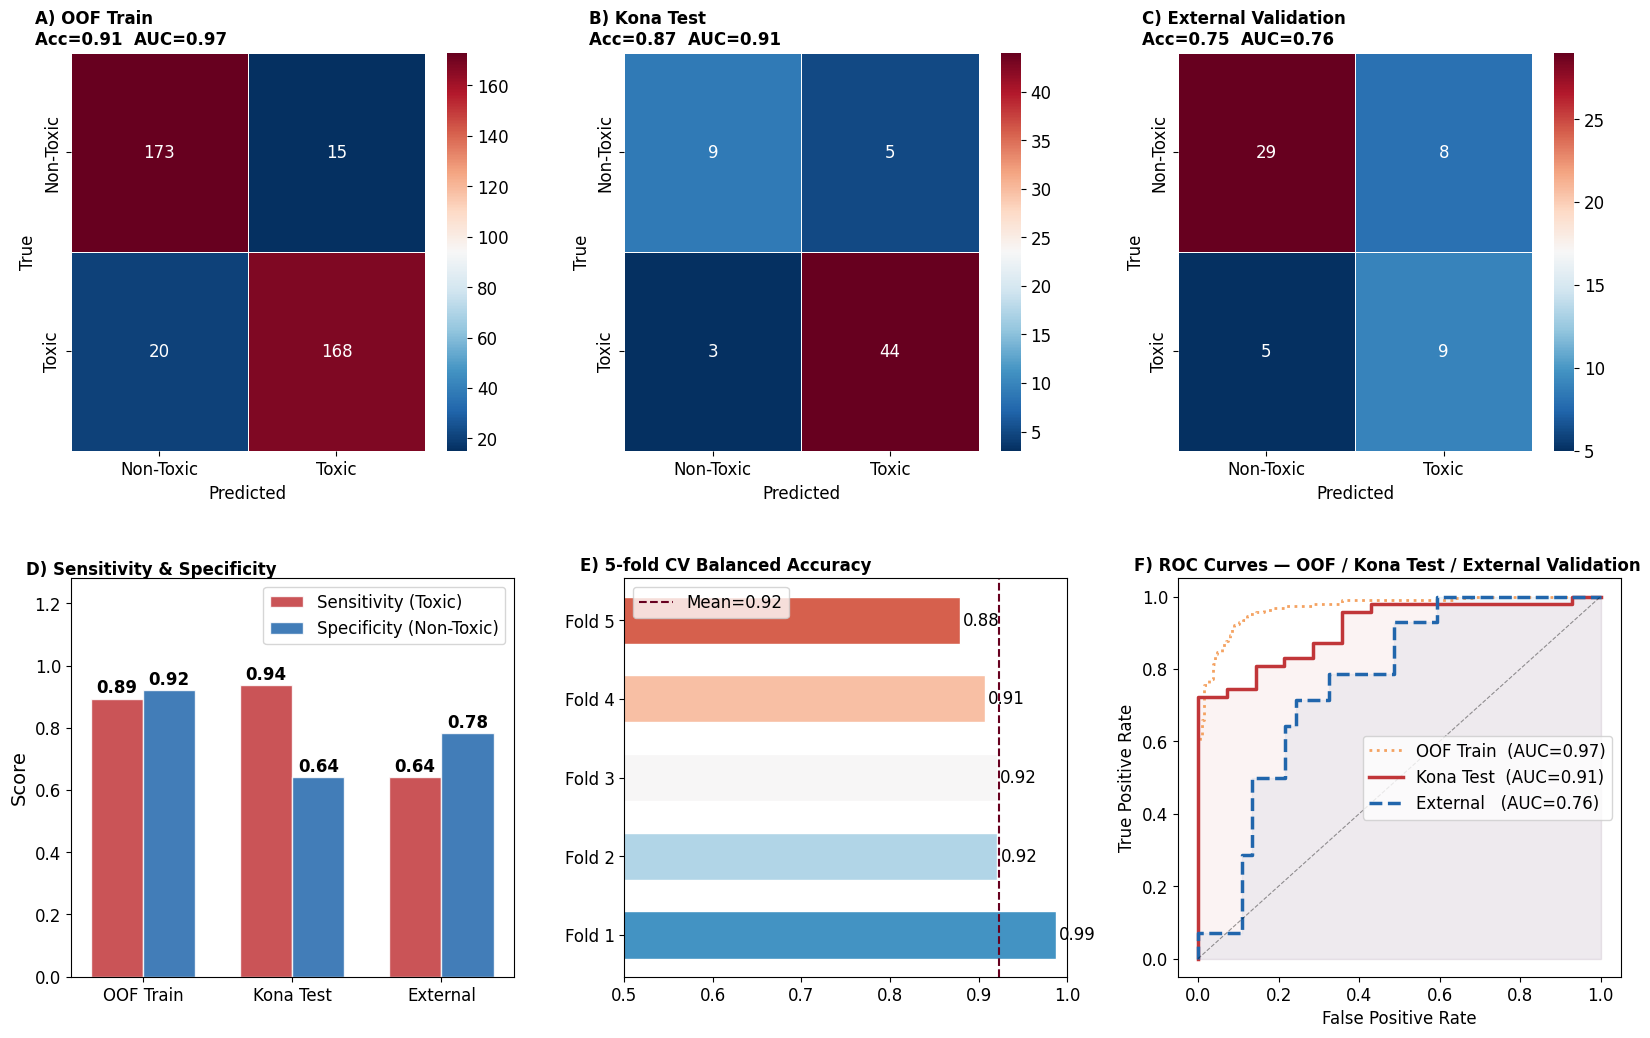

In [42]:
from sklearn.calibration import calibration_curve

fig = plt.figure(figsize=(20, 12))
gs  = fig.add_gridspec(2, 3, hspace=0.32, wspace=0.25)
#fig.suptitle(
#    'Stage 1 — Stacking Meta-Learner  (ET + GB + RF + LR → LogReg)\n'
#    'OOF Train (SMOTE) | Kona Test Set | External Validation  (Sun 2011 + Peng 2020)',
#    fontsize=13, fontweight='bold'
#)

BLUE, RED, GREEN, AMBER = '#2166AC', '#C13639', '#1B7837', '#F4A261'

# ── Row 0 ──────────────────────────────────────────────────────────

# A: Confusion matrix — OOF Train
ax = fig.add_subplot(gs[0, 0])
sns.heatmap(cm_oof_mat, annot=True, fmt='d', cmap='RdBu_r',
            xticklabels=le_y.classes_, yticklabels=le_y.classes_,
            ax=ax, linewidths=0.5, linecolor='white', annot_kws={'size': 12})
ax.set_title(f'A) OOF Train\nAcc={oof_acc_v:.2f}  AUC={auc_oof:.2f}',
             fontweight='bold', loc='left', fontsize=12,x=-0.1)
ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('True', fontsize=12)

# B: Confusion matrix — Kona Test
ax = fig.add_subplot(gs[0, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='RdBu_r',
            xticklabels=le_y.classes_, yticklabels=le_y.classes_,
            ax=ax, linewidths=0.5, linecolor='white', annot_kws={'size': 12})
ax.set_title(f'B) Kona Test\nAcc={test_acc:.2f}  AUC={auc_te:.2f}',
             fontweight='bold', loc='left', fontsize=12, x=-0.1)
ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('True', fontsize=12)

# C: Confusion matrix — External
ax = fig.add_subplot(gs[0, 2])
sns.heatmap(cm_ext, annot=True, fmt='d', cmap='RdBu_r',
            xticklabels=le_y.classes_, yticklabels=le_y.classes_,
            ax=ax, linewidths=0.5, linecolor='white', annot_kws={'size': 12})
ax.set_title(f'C) External Validation  \nAcc={ext_acc:.2f}  AUC={auc_ext:.2f}',
             fontweight='bold', loc='left', fontsize=12, x=-0.1)
ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('True', fontsize=12)

# D: Sensitivity / Specificity
ax = fig.add_subplot(gs[1, 0])

def sens_spec(cm_m):
    tn, fp, fn, tp = cm_m.ravel()
    return tp / (tp + fn), tn / (tn + fp)

ss_oof = sens_spec(cm_oof_mat)
ss_te  = sens_spec(cm)
ss_ext = sens_spec(cm_ext)

x = np.arange(3); w = 0.35
b1 = ax.bar(x - w/2, [ss_oof[0], ss_te[0], ss_ext[0]], w,
            label='Sensitivity (Toxic)',     color=RED,  alpha=0.85, edgecolor='white')
b2 = ax.bar(x + w/2, [ss_oof[1], ss_te[1], ss_ext[1]], w,
            label='Specificity (Non-Toxic)', color=BLUE, alpha=0.85, edgecolor='white')
for bar, val in list(zip(b1, [ss_oof[0], ss_te[0], ss_ext[0]])) + \
                list(zip(b2, [ss_oof[1], ss_te[1], ss_ext[1]])):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.018,
            f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['OOF Train', 'Kona Test', 'External'], fontsize=12)
ax.set_ylim(0, 1.28); ax.set_ylabel('Score')
ax.set_title('D) Sensitivity & Specificity', fontweight='bold', loc='left', fontsize=12, x=-0.1,pad=2)
ax.legend(fontsize=12); ax.grid(False)

# ── Row 1 ──────────────────────────────────────────────────────────

# E: 5-fold CV balanced accuracy
ax = fig.add_subplot(gs[1, 1])
bar_colors = plt.cm.RdBu_r(np.linspace(0.2, 0.8, 5))
bars = ax.barh([f'Fold {i+1}' for i in range(5)], cv_accs,
               color=bar_colors, edgecolor='white', height=0.6)
ax.axvline(cv_accs.mean(), color='#67001F', ls='--', lw=1.5,
           label=f'Mean={cv_accs.mean():.2f}')
ax.set_xlim(0.5, 1.0)
ax.set_title('E) 5-fold CV Balanced Accuracy',
             fontweight='bold', loc='left', fontsize=12, x=-0.1)
ax.legend(fontsize=12); ax.grid(False)
for bar, val in zip(bars, cv_accs):
    ax.text(val + 0.004, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=12)

# F: ROC curves (2-column wide)
ax = fig.add_subplot(gs[1, 2])
ax.plot(fpr_oof, tpr_oof, color=AMBER, lw=2,   ls=':',
        label=f'OOF Train  (AUC={auc_oof:.2f})')
ax.plot(fpr_te,  tpr_te,  color=RED,   lw=2.5,
        label=f'Kona Test  (AUC={auc_te:.2f})')
ax.plot(fpr_ext, tpr_ext, color=BLUE,  lw=2.5, ls='--',
        label=f'External   (AUC={auc_ext:.2f})')
ax.fill_between(fpr_te,  tpr_te,  alpha=0.06, color=RED)
ax.fill_between(fpr_ext, tpr_ext, alpha=0.06, color=BLUE)
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.4)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('F) ROC Curves — OOF / Kona Test / External Validation',
             fontweight='bold', loc='left', fontsize=12, x=-0.1)
ax.legend(fontsize=12); ax.grid(False)
plt.savefig('Fig_Stage1_MultiPanel.png', dpi=600, bbox_inches='tight')
plt.show()

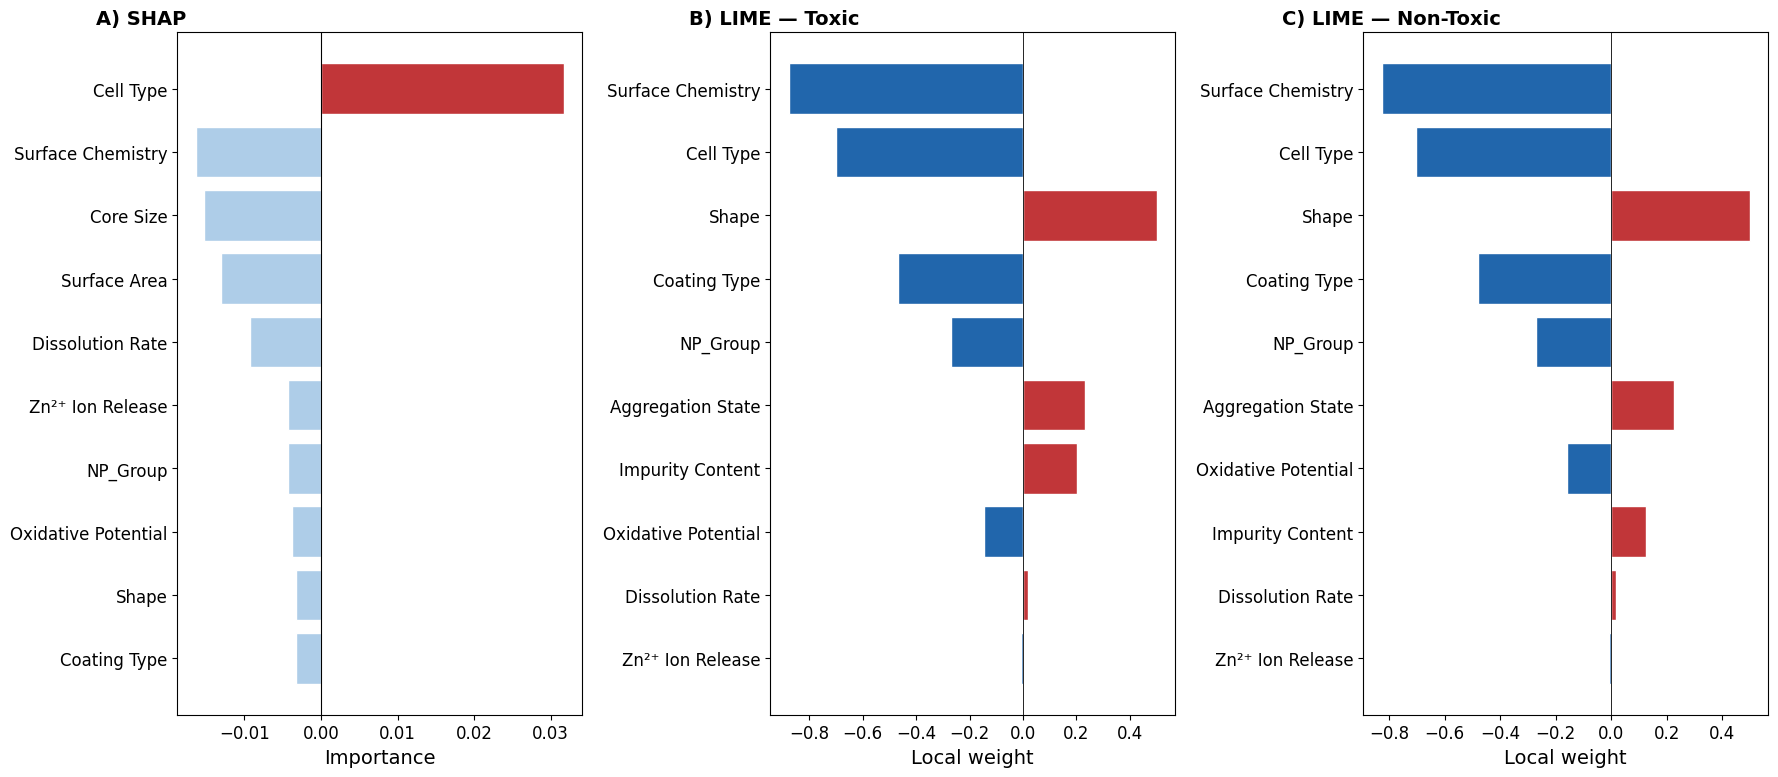

In [67]:
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
# ── Aggregate helper ──────────────────────────────────────────────
def aggregate_by_group(coefs_raw, feat_list, cat_cols):
    agg = {}
    for cat in cat_cols:
        members = [f for f in feat_list if f.startswith(cat + '_')]
        if not members:
            continue
        vals = coefs_raw.loc[members]
        dominant_feat  = vals.abs().idxmax()
        dominant_val   = vals[dominant_feat]
        agg[cat] = dominant_val
    for feat in feat_list:
        is_dummy = any(feat.startswith(cat + '_') for cat in cat_cols)
        if not is_dummy:
            label = (feat.replace(' (µg/mL)','').replace(' (hrs)','')
                        .replace(' (nm)','').replace(' (mV)','')
                        .replace(' (m²/g)','').replace(' (mg/L)','')
                        .replace(' (%)', ''))
            agg[label] = coefs_raw[feat]
    return pd.Series(agg).sort_values(key=abs, ascending=False)
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})
# ── ET fit ────────────────────────────────────────────────────────
best_stage1_et = ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1)
best_stage1_et.fit(X_tr_bal, y_tr_bal)

# ── Permutation importance ────────────────────────────────────────
pi = permutation_importance(best_stage1_et, X_te, y_te, n_repeats=30, random_state=42, n_jobs=-1)
pi_raw = pd.Series(pi.importances_mean, index=FEAT_FINAL)
pi_agg = aggregate_by_group(pi_raw, FEAT_FINAL, CAT_COLS)

# ── LIME helper ───────────────────────────────────────────────────
def lime_explain_clf(model, X_bg, instance, feat_names, n_samples=200, rs=42):
    rng = np.random.RandomState(rs)
    perturbed = np.array([
        X_bg[rng.randint(len(X_bg))] + rng.normal(0, 0.10, X_bg.shape[1]) * X_bg.std(0)
        for _ in range(n_samples)
    ])
    dists   = np.sqrt(((perturbed - instance) ** 2).sum(axis=1))
    weights = np.exp(-dists / max(dists.mean(), 1e-8))
    y_pert  = model.predict_proba(perturbed)[:, 1]
    lr = LinearRegression()
    lr.fit(perturbed, y_pert, sample_weight=weights)
    return pd.Series(lr.coef_, index=feat_names)

# ── LIME cases ────────────────────────────────────────────────────
probs_te     = best_stage1_et.predict_proba(X_te)[:, 1]
idx_toxic    = int(np.argmax(probs_te))
idx_nontoxic = int(np.argmin(probs_te))

lime_cases = {
    'Toxic': X_te.values[idx_toxic],
    'Non-Toxic': X_te.values[idx_nontoxic],
}

lime_results_raw = {
    label: lime_explain_clf(best_stage1_et, X_te.values, inst, FEAT_FINAL)
    for label, inst in lime_cases.items()
}

lime_results_agg = {
    label: aggregate_by_group(coefs, FEAT_FINAL, CAT_COLS)
    for label, coefs in lime_results_raw.items()
}

# ── Figure ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
BLUE, RED = '#2166AC', '#C13639'

# A — SHAP (Permutation importance)
ax = axes[0]
top10 = pi_agg.head(10)
bc = ['#C13639' if v > 0.01 else ('#2166AC' if v > 0 else '#AECDE8') for v in top10.values]
ax.barh(top10.index[::-1], top10.values[::-1], color=bc[::-1], edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('A) SHAP', fontweight='bold', loc='left', fontsize=14,x=-0.2)
ax.set_xlabel('Importance')
ax.grid(False)
#for i, (feat, val) in enumerate(zip(top10.index[::-1], top10.values[::-1])):
#    ax.text(max(val, 0) + 0.0005, i, f'{val:.3f}', va='center', fontsize=12)

# B — LIME Toxic
ax = axes[1]
coefs_b = lime_results_agg['Toxic'].head(10)
vals_b  = coefs_b.values
clr_b   = ['#C13639' if v > 0 else '#2166AC' for v in vals_b]
ax.barh(coefs_b.index[::-1], vals_b[::-1], color=clr_b[::-1], edgecolor='white')
ax.axvline(0, color='black', lw=0.6)
ax.set_title('B) LIME — Toxic', fontweight='bold', loc='left', fontsize=14,x=-0.2)
ax.set_xlabel('Local weight')
ax.grid(False)

# C — LIME Non-Toxic
ax = axes[2]
coefs_c = lime_results_agg['Non-Toxic'].head(10)
vals_c  = coefs_c.values
clr_c   = ['#C13639' if v > 0 else '#2166AC' for v in vals_c]
ax.barh(coefs_c.index[::-1], vals_c[::-1], color=clr_c[::-1], edgecolor='white')
ax.axvline(0, color='black', lw=0.6)
ax.set_title('C) LIME — Non-Toxic', fontweight='bold', loc='left', fontsize=14,x=-0.2)
ax.set_xlabel('Local weight')
ax.grid(False)

plt.tight_layout()
plt.savefig('Fig_SHAP_LIME_Stage1.png', dpi=600, bbox_inches='tight')
plt.show()


## 4. Stage 2 — Biological Endpoint Regression

**Input:** Physicochemical features + `TCP_prob` (soft OOF probability from Stage 1)  
**Targets:** ROS Production (%), Membrane Damage (%), Apoptosis (%), Necrosis (%)  
**Model:** ExtraTreesRegressor with class-specific sub-models  

Three versions compared:
1. **No TCP** — baseline, physicochemical only
2. **OOF TCP** — correct method, leakage-free
3. **True Label TCP** — theoretical upper bound (shows cost of doing it right)

In [70]:
FEAT_S2 = FEAT_FINAL + ['TCP_prob']
df_enc['TCP_bin'] = (df_enc['TCP_prob'] >= 0.5).astype(float)

# Stage 2'de TCP_bin kullan
FEAT_S2 = FEAT_FINAL + ['TCP_bin']
# TCP_prob kolonunu df_enc'e ekle
df_enc['TCP_prob'] = np.nan
df_enc.loc[X_tr.index, 'TCP_prob'] = oof_orig_prob
df_enc.loc[X_te.index, 'TCP_prob'] = te_meta_prob

kf5     = KFold(n_splits=5, shuffle=True, random_state=42)
results = {bio: {} for bio in BIO_COLS}

for bio in BIO_COLS:
    # df_enc üzerinden çalış — get_dummies sonrası doğru DataFrame
    df_t = df_enc.dropna(subset=[bio])
    tr_m = df_t.index.isin(X_tr.index)
    te_m = df_t.index.isin(X_te.index)

    X2tr = df_t[FEAT_S2][tr_m];  y2tr = df_t[bio][tr_m]
    X2te = df_t[FEAT_S2][te_m];  y2te = df_t[bio][te_m]

    imp2   = SimpleImputer(strategy='median')
    X2tr_i = imp2.fit_transform(X2tr)
    X2te_i = imp2.transform(X2te)

    reg = ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    cv  = cross_val_score(reg, X2tr_i, y2tr, cv=kf5, scoring='r2')
    reg.fit(X2tr_i, y2tr)

    yp    = reg.predict(X2te_i)
    r2te  = r2_score(y2te, yp)
    r2tr  = r2_score(y2tr, reg.predict(X2tr_i))
    rmse  = mean_squared_error(y2te, yp) ** 0.5
    mae   = mean_absolute_error(y2te, yp)

    results[bio]['oof_tcp'] = {
        'Train_R2': r2tr, 'Test_R2': r2te,
        'RMSE': rmse, 'MAE': mae,
        'CV_R2': cv.mean(), 'CV_Std': cv.std(),
        'y_true': y2te, 'y_pred': yp }

    print(f"{bio:22s}  Train={r2tr:.3f}  CV={cv.mean():.3f}±{cv.std():.3f}  Test={r2te:.3f}")

ROS Production          Train=1.000  CV=0.159±0.128  Test=0.254
Membrane Damage (%)     Train=1.000  CV=0.087±0.312  Test=0.224
Apoptosis (%)           Train=1.000  CV=0.084±0.192  Test=0.127
Necrosis (%)            Train=1.000  CV=0.227±0.176  Test=0.860


In [71]:
# True label TCP for upper-bound comparison
df_enc['TCP_true'] = np.nan
df_enc.loc[X_tr.index, 'TCP_true'] = y_tr.values.astype(float)
df_enc.loc[X_te.index, 'TCP_true'] = y_te.values.astype(float)

results = {bio: {} for bio in BIO_COLS}

print('=' * 88)
print('STAGE 2 — THREE-WAY COMPARISON')
print(f'{"":22s}  {"No TCP":>7s}  {"OOF TCP":>9s} {"Δ_oof":>7s}  {"True TCP":>9s} {"Δ_true":>8s}')
print('=' * 88)

for bio in BIO_COLS:
    df_t = df_enc.dropna(subset=[bio])
    tr_m = df_t.index.isin(X_tr.index)
    te_m = df_t.index.isin(X_te.index)
    y2tr = df_t[bio][tr_m]; y2te = df_t[bio][te_m]
    imp2 = SimpleImputer(strategy='median')

    for tag, feat_extra in [
        ('no_tcp',   []),
        ('oof_tcp',  ['TCP_prob']),
        ('true_tcp', ['TCP_true']),
    ]:
        feat_set = FEAT_FINAL + feat_extra
        X2tr = df_t[feat_set][tr_m]; X2te = df_t[feat_set][te_m]
        X2tr_i = imp2.fit_transform(X2tr); X2te_i = imp2.transform(X2te)

        reg = ExtraTreesRegressor(
            n_estimators=300, max_depth=12,
            min_samples_split=6, min_samples_leaf=3,
            random_state=42, n_jobs=-1
        )
        reg.fit(X2tr_i, y2tr)

        cv   = cross_val_score(reg, X2tr_i, y2tr, cv=kf10, scoring='r2', n_jobs=-1)
        r2te = r2_score(y2te, reg.predict(X2te_i))
        r2tr = r2_score(y2tr, reg.predict(X2tr_i))
        rmse = mean_squared_error(y2te, reg.predict(X2te_i)) ** 0.5
        mae  = mean_absolute_error(y2te, reg.predict(X2te_i))

        results[bio][tag] = {
            'Train_R2': r2tr, 'Test_R2': r2te, 'RMSE': rmse, 'MAE': mae,
            'CV_R2': cv.mean(), 'CV_Std': cv.std(),
            'y_true': y2te, 'y_pred': reg.predict(X2te_i) }

    r_no   = results[bio]['no_tcp']['Test_R2']
    r_oof  = results[bio]['oof_tcp']['Test_R2']
    r_true = results[bio]['true_tcp']['Test_R2']
    d_oof  = r_oof  - r_no;  so = '+' if d_oof  >= 0 else ''
    d_true = r_true - r_no;  st = '+' if d_true >= 0 else ''
    print(f"{bio:22s}  {r_no:7.3f}  {r_oof:9.3f} {so}{d_oof:6.3f}  "
          f"{r_true:9.3f} {st}{d_true:7.3f}")

STAGE 2 — THREE-WAY COMPARISON
                         No TCP    OOF TCP   Δ_oof   True TCP   Δ_true
ROS Production            0.363      0.352 -0.010      0.580 +  0.217
Membrane Damage (%)       0.616      0.615 -0.001      0.737 +  0.121
Apoptosis (%)             0.531      0.518 -0.013      0.580 +  0.049
Necrosis (%)              0.541      0.543 + 0.001      0.535  -0.006


In [72]:
# TCP_bin kolonunu df_enc'e ekle — TCP_prob'un binary versiyonu
df_enc['TCP_bin'] = (df_enc['TCP_prob'] >= 0.5).astype(float)

# True label TCP for upper-bound comparison
df_enc['TCP_true'] = np.nan
df_enc.loc[X_tr.index, 'TCP_true'] = y_tr.values.astype(float)
df_enc.loc[X_te.index, 'TCP_true'] = y_te.values.astype(float)

results = {bio: {} for bio in BIO_COLS}

print('=' * 88)
print('STAGE 2 — THREE-WAY COMPARISON')
print(f'{"":22s}  {"No TCP":>7s}  {"OOF_bin":>9s} {"Δ_bin":>7s}  {"True TCP":>9s} {"Δ_true":>8s}')
print('=' * 88)

for bio in BIO_COLS:
    df_t = df_enc.dropna(subset=[bio])
    tr_m = df_t.index.isin(X_tr.index)
    te_m = df_t.index.isin(X_te.index)
    y2tr = df_t[bio][tr_m]; y2te = df_t[bio][te_m]
    imp2 = SimpleImputer(strategy='median')

    for tag, feat_extra in [
        ('no_tcp',   []),
        ('oof_tcp',  ['TCP_bin']),    # ← TCP_prob yerine TCP_bin
        ('true_tcp', ['TCP_true']),
    ]:
        feat_set = FEAT_FINAL + feat_extra
        X2tr = df_t[feat_set][tr_m]; X2te = df_t[feat_set][te_m]
        X2tr_i = imp2.fit_transform(X2tr); X2te_i = imp2.transform(X2te)

        reg = ExtraTreesRegressor(
            n_estimators=300, max_depth=12,
            min_samples_split=6, min_samples_leaf=3,
            random_state=42, n_jobs=-1
        )
        reg.fit(X2tr_i, y2tr)
        cv   = cross_val_score(reg, X2tr_i, y2tr, cv=kf10, scoring='r2', n_jobs=-1)
        r2te = r2_score(y2te, reg.predict(X2te_i))
        r2tr = r2_score(y2tr, reg.predict(X2tr_i))
        rmse = mean_squared_error(y2te, reg.predict(X2te_i)) ** 0.5
        mae  = mean_absolute_error(y2te, reg.predict(X2te_i))

        results[bio][tag] = {
            'Train_R2': r2tr, 'Test_R2': r2te, 'RMSE': rmse, 'MAE': mae,
            'CV_R2': cv.mean(), 'CV_Std': cv.std(),
            'y_true': y2te, 'y_pred': reg.predict(X2te_i)
        }

    r_no   = results[bio]['no_tcp']['Test_R2']
    r_oof  = results[bio]['oof_tcp']['Test_R2']
    r_true = results[bio]['true_tcp']['Test_R2']
    d_oof  = r_oof  - r_no;  so = '+' if d_oof >= 0 else ''
    d_true = r_true - r_no;  st = '+' if d_true >= 0 else ''
    print(f"{bio:22s}  {r_no:7.3f}  {r_oof:9.3f} {so}{d_oof:6.3f}  "
          f"{r_true:9.3f} {st}{d_true:7.3f}")

print()
print('OOF_bin TCP = leakage-free binary prediction (TCP_prob ≥ 0.5) — deployable')
print('True TCP    = theoretical upper bound — NOT deployable')

STAGE 2 — THREE-WAY COMPARISON
                         No TCP    OOF_bin   Δ_bin   True TCP   Δ_true
ROS Production            0.363      0.370 + 0.008      0.580 +  0.217
Membrane Damage (%)       0.616      0.615 -0.001      0.737 +  0.121
Apoptosis (%)             0.531      0.529 -0.003      0.580 +  0.049
Necrosis (%)              0.541      0.542 + 0.000      0.535  -0.006

OOF_bin TCP = leakage-free binary prediction (TCP_prob ≥ 0.5) — deployable
True TCP    = theoretical upper bound — NOT deployable


In [76]:
same_count = (df_enc['TCP_bin'] == df_enc['TCP_true']).sum()
print(same_count)

177


In [52]:
results[bio][tag] = {
    'Train_R2': r2tr,
    'Test_R2':  r2te,
    'RMSE':     rmse,
    'MAE':      mae,
    'CV_R2':    cv.mean(),
    'CV_Std':   cv.std(),
    'y_true':   y2te,
    'y_pred':   reg.predict(X2te_i)
}
# Figürden önce train R² ve metriklerini hesapla
# results dict'inden reg'i tekrar fit et
import copy as _c
from sklearn.ensemble import ExtraTreesRegressor

REG_MAP = {
    'ROS Production':      ExtraTreesRegressor(n_estimators=300, max_depth=12,
                               min_samples_split=6, min_samples_leaf=3,
                               random_state=42, n_jobs=-1),
    'Membrane Damage (%)': ExtraTreesRegressor(n_estimators=300, max_depth=12,
                               min_samples_split=6, min_samples_leaf=3,
                               random_state=42, n_jobs=-1),
    'Apoptosis (%)':       ExtraTreesRegressor(n_estimators=300, max_depth=12,
                               min_samples_split=6, min_samples_leaf=3,
                               random_state=42, n_jobs=-1),
    'Necrosis (%)':        ExtraTreesRegressor(n_estimators=300, max_depth=12,
                               min_samples_split=6, min_samples_leaf=3,
                               random_state=42, n_jobs=-1),
}

stage2_regs = {}
feat_set    = FEAT_FINAL + ['TCP_prob']

for bio in BIO_COLS:
    df_t  = df_enc.dropna(subset=[bio])
    tr_m  = df_t.index.isin(X_tr.index)
    X2tr  = df_t[feat_set][tr_m];  y2tr = df_t[bio][tr_m]
    imp2  = SimpleImputer(strategy='median')
    X2tr_i = imp2.fit_transform(X2tr)
    reg   = _c.deepcopy(REG_MAP[bio])
    reg.fit(X2tr_i, y2tr)
    stage2_regs[bio] = reg

In [25]:
df_enc

,Nanoparticle,Core Size (nm),Zeta Potential (mV),Surface Area (m²/g),Dissolution Rate (mg/L),Zn²⁺ Ion Release (mg/L),Impurity Content (%),Exposure Dosage (µg/mL),Exposure Time (hrs),ROS Production,...,Cell Type_WEHI-3B (Murine Myelocytic Leukemia Cells),Cell Type_WI-38 (Normal Lung Fibroblast),Cell Type_Zebrafish Embryo,Cell Type_Zebrafish Embryos,Cell Type_hCMEC/D3 (human cerebral microvascular endothelial cells),Cell Type_hiPSC-Derived Cardiomyocytes,TC,TCP_prob,TCP_bin,TCP_true
0,SiO₂,20.0,-30.0,150.0,0.5,0.0,0.10,25.0,24.0,26.6,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0.068979,0.0,1.0
1,SiO₂,50.0,-35.0,100.0,0.3,0.0,0.10,50.0,24.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.964694,1.0,0.0
2,SiO₂,20.0,-30.0,150.0,0.5,0.0,0.10,25.0,24.0,26.6,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0.369099,0.0,1.0
3,SiO₂,50.0,-35.0,100.0,0.3,0.0,0.10,50.0,24.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.130650,0.0,0.0
4,SiO₂,15.0,-25.0,200.0,0.7,0.0,0.10,25.0,72.0,40.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0.091708,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,ZnO,50.0,-11.5,85.3,11.0,6.0,0.05,3.0,120.0,60.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0.326129,0.0,1.0
300,ZnO,20.0,-15.0,100.0,10.0,5.0,0.02,1.0,72.0,60.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0.874026,1.0,1.0
301,ZnO,30.0,-12.0,85.3,11.0,6.0,0.05,20.0,12.0,60.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0.963778,1.0,1.0
302,ZnO,70.0,-15.0,90.0,12.0,7.0,0.02,50.0,48.0,60.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0.949002,1.0,1.0


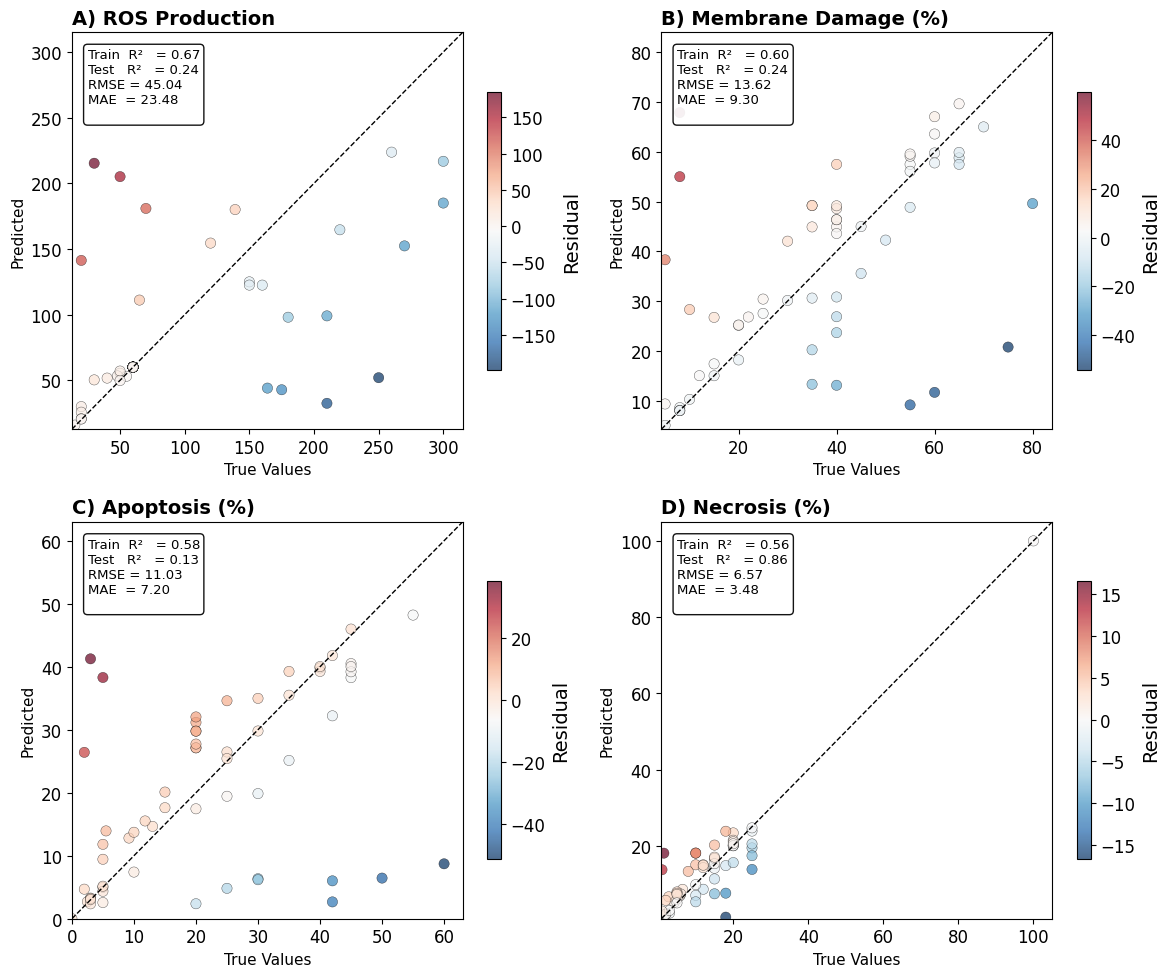

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, bio in enumerate(BIO_COLS):
    res = results[bio]['oof_tcp']
    yt  = res['y_true']; yp = res['y_pred']
    ax  = axes.flatten()[idx]
    sc  = ax.scatter(yt, yp, c=(yp - yt), cmap='RdBu_r',
                     alpha=0.7, edgecolors='k', linewidths=0.3, s=55)
    lims = [min(yt.min(), yp.min()) * 0.85, max(yt.max(), yp.max()) * 1.05]
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(f'{chr(65+idx)}) {bio}', fontweight='bold', loc='left', fontsize=14)
    ax.set_xlabel('True Values', fontsize=11)
    ax.set_ylabel('Predicted',   fontsize=11)

    # ── Kona train metrics ────────────────────────────────────────
    df_t   = df_enc.dropna(subset=[bio])
    tr_m   = df_t.index.isin(X_tr.index)
    feat_set = FEAT_FINAL + ['TCP_prob']
    X2tr   = df_t[feat_set][tr_m]
    y2tr   = df_t[bio][tr_m]
    imp2   = SimpleImputer(strategy='median')
    X2tr_i = imp2.fit_transform(X2tr)
    yp_tr  = stage2_regs[bio].predict(X2tr_i)

    r2_train   = r2_score(y2tr, yp_tr)
    rmse_train = mean_squared_error(y2tr, yp_tr) ** 0.5
    mae_train  = mean_absolute_error(y2tr, yp_tr)

    # ── Kona test metrics ─────────────────────────────────────────
    r2_test   = res['Test_R2']
    rmse_test = res['RMSE']
    mae_test  = res['MAE']

    ax.text(0.04, 0.96,
            f"Train  R²   = {r2_train:.2f}\n"
            f"Test   R²   = {r2_test:.2f}\n"
            f"RMSE = {rmse_train:.2f}\n"
            f"MAE  = {mae_train:.2f}\n",
            transform=ax.transAxes, fontsize=9.5, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.92))
    ax.grid(False)
    plt.colorbar(sc, ax=ax, shrink=0.7, label='Residual')

plt.tight_layout()
plt.savefig('Fig3_Stage2_Regression.png', dpi=600, bbox_inches='tight')
plt.show()


In [54]:
# Three-way comparison figure
bio_short = ['ROS', 'Membrane\nDamage', 'Apoptosis', 'Necrosis']
r2_no    = [results[b]['no_tcp']['Test_R2']   for b in BIO_COLS]
r2_oof   = [results[b]['oof_tcp']['Test_R2']  for b in BIO_COLS]
r2_true  = [results[b]['true_tcp']['Test_R2'] for b in BIO_COLS]

x = np.arange(len(BIO_COLS)); w = 0.25
fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(x - w,   r2_no,   w, label='No TCP (baseline)',         color=BLUE,  alpha=0.88, edgecolor='white')
ax.bar(x,       r2_oof,  w, label='OOF TCP',  color=RED,   alpha=0.88, edgecolor='white')
ax.bar(x + w,   r2_true, w, label='True Label TCP',color=AMBER, alpha=0.88, edgecolor='white',
       hatch='//', linewidth=0.5)

for i, (no, oof, true) in enumerate(zip(r2_no, r2_oof, r2_true)):
    d_oof  = oof  - no; so = '+' if d_oof  >= 0 else ''
    d_true = true - no
    ax.text(i,     oof  + 0.015, f'{so}{d_oof:.2f}',  ha='center', fontsize=9,
            color=GREEN if d_oof > 0 else RED, fontweight='bold')
    ax.text(i + w, true + 0.015, f'+{d_true:.2f}', ha='center', fontsize=9,
            color=AMBER, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(bio_short, fontsize=11)
ax.set_ylabel('Test R²', fontsize=11); ax.set_ylim(0, 0.95)
ax.axhline(0, color='gray', lw=0.5)
ax.legend(fontsize=9); ax.grid(False)

plt.tight_layout()
plt.savefig('Fig4_ThreeWay_Comparison.png', dpi=600, bbox_inches='tight')
plt.show()


KeyError: 'no_tcp'

In [ ]:
ORDINAL  = ['Low', 'Moderate', 'High']
BIO_COLS = ['Membrane Damage (%)', 'Apoptosis (%)', 'Necrosis (%)', 'ROS Production']

THRESH = {
    'Membrane Damage (%)': [0, 15, 40, 200],
    'Apoptosis (%)':        [0, 10, 30, 200],
    'Necrosis (%)':         [0, 10, 20, 200],
    'ROS Production':       [0, 50, 150, 2000],
}

for bio, bins in THRESH.items():
    df[bio + '_cls'] = pd.cut(df[bio], bins=bins, labels=ORDINAL,
                               right=True, include_lowest=True)
    print(f"{bio}: {df[bio+'_cls'].value_counts().to_dict()}")

Membrane Damage (%): {'High': 119, 'Moderate': 105, 'Low': 80}
Apoptosis (%): {'Moderate': 109, 'Low': 99, 'High': 96}
Necrosis (%): {'Low': 152, 'Moderate': 120, 'High': 32}
ROS Production: {'Moderate': 167, 'Low': 74, 'High': 63}


In [ ]:
# df (kona ham verisi) üzerinde threshold uygula
for bio, bins in THRESH.items():
    df[bio + '_cls'] = pd.cut(df[bio], bins=bins, labels=ORDINAL,
                               right=True, include_lowest=True)

# df_enc'e de ekle — index aynı olduğu için direkt atama
for bio in BIO_COLS:
    col_cls = bio + '_cls'
    df_enc[col_cls] = df[col_cls].values

# Kontrol
print("Kolonlar eklendi:")
for bio in BIO_COLS:
    col_cls = bio + '_cls'
    print(f"  {col_cls}: {df_enc[col_cls].value_counts().to_dict()}")

Kolonlar eklendi:
  Membrane Damage (%)_cls: {'High': 119, 'Moderate': 105, 'Low': 80}
  Apoptosis (%)_cls: {'Moderate': 109, 'Low': 99, 'High': 96}
  Necrosis (%)_cls: {'Low': 152, 'Moderate': 120, 'High': 32}
  ROS Production_cls: {'Moderate': 167, 'Low': 74, 'High': 63}


In [ ]:
from sklearn.utils import all_estimators
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

EXCL = {'ClassifierChain','MultiOutputClassifier','OneVsOneClassifier',
        'OneVsRestClassifier','OutputCodeClassifier','VotingClassifier',
        'StackingClassifier','CalibratedClassifierCV','CheckingClassifier',
        'DummyClassifier','FixedThresholdClassifier','TunedThresholdClassifierCV',
        'SelfTrainingClassifier'}

ord_enc_map = {'Low': 0, 'Moderate': 1, 'High': 2}
best_models = {}

for bio in BIO_COLS:
    col_cls = bio + '_cls'
    df_t    = df_enc.dropna(subset=[col_cls])
    y_cls   = df_t[col_cls].map(ord_enc_map)
    tr_m    = df_t.index.isin(X_tr.index)
    te_m    = df_t.index.isin(X_te.index)

    X2tr = df_t[FEAT_S2][tr_m];  y2tr = y_cls[tr_m]
    X2te = df_t[FEAT_S2][te_m];  y2te = y_cls[te_m]

    imp2   = SimpleImputer(strategy='median')
    Xtr_i  = imp2.fit_transform(X2tr)
    Xte_i  = imp2.transform(X2te)

    rows = []
    for name, cls in all_estimators(type_filter='classifier'):
        if name in EXCL:
            continue
        try:
            clf = Pipeline([('sc', StandardScaler()), ('c', cls())])
            clf.fit(Xtr_i, y2tr)
            yp  = clf.predict(Xte_i)
            rows.append({
                'Model':    name,
                'Accuracy': round(accuracy_score(y2te, yp), 4),
                'F1':       round(f1_score(y2te, yp, average='macro', zero_division=0), 4),
            })
        except:
            pass

    rdf = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
    best_models[bio] = rdf.iloc[0]['Model']
    print(f"  {bio:22s} → {best_models[bio]:35s}  Acc={rdf.iloc[0]['Accuracy']:.4f}")

  Membrane Damage (%)    → LogisticRegression                   Acc=0.6721
  Apoptosis (%)          → LogisticRegression                   Acc=0.7541
  Necrosis (%)           → DecisionTreeClassifier               Acc=0.7049
  ROS Production         → BaggingClassifier                    Acc=0.7705


In [ ]:
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             f1_score, precision_score, confusion_matrix)

stage2    = {}
stage2_clf = {}
stage2_imp = {}

for bio in BIO_COLS:
    col_cls = bio + '_cls'
    df_t    = df_enc.dropna(subset=[col_cls])
    y_cls   = df_t[col_cls].map(ord_enc_map)
    tr_m    = df_t.index.isin(X_tr.index)
    te_m    = df_t.index.isin(X_te.index)

    X2tr = df_t[FEAT_S2][tr_m];  y2tr = y_cls[tr_m]
    X2te = df_t[FEAT_S2][te_m];  y2te = y_cls[te_m]

    imp2  = SimpleImputer(strategy='median')
    Xtr_i = imp2.fit_transform(X2tr)
    Xte_i = imp2.transform(X2te)

    best_cls = dict(all_estimators(type_filter='classifier'))[best_models[bio]]
    clf      = Pipeline([('sc', StandardScaler()), ('c', best_cls())])
    clf.fit(Xtr_i, y2tr)
    yp = clf.predict(Xte_i)

    try:
        auc = roc_auc_score(y2te, clf.predict_proba(Xte_i),
                            multi_class='ovr', average='macro')
    except:
        auc = float('nan')

    stage2[bio] = {
        'model': best_models[bio],
        'acc':   accuracy_score(y2te, yp),
        'auc':   auc,
        'f1':    f1_score(y2te, yp, average='macro', zero_division=0),
        'prec':  precision_score(y2te, yp, average='macro', zero_division=0),
        'cm_te': confusion_matrix(y2te, yp, labels=[0, 1, 2]),
    }
    stage2_clf[bio] = clf
    stage2_imp[bio] = imp2

    print(f"{bio:22s}  Acc={stage2[bio]['acc']:.3f}  AUC={stage2[bio]['auc']:.3f}  "
          f"F1={stage2[bio]['f1']:.3f}  Prec={stage2[bio]['prec']:.3f}")

Membrane Damage (%)     Acc=0.672  AUC=0.836  F1=0.676  Prec=0.711
Apoptosis (%)           Acc=0.754  AUC=0.882  F1=0.754  Prec=0.763
Necrosis (%)            Acc=0.656  AUC=0.736  F1=0.619  Prec=0.625
ROS Production          Acc=0.754  AUC=0.884  F1=0.695  Prec=0.698


In [ ]:
# de_raw ve de_enc önceki hücreden bellekte olmalı
# TCP_true external için Stage 1 meta-learner tahmininden

for bio, bins in THRESH.items():
    de_raw[bio + '_cls'] = pd.cut(de_raw[bio], bins=bins, labels=ORDINAL,
                                   right=True, include_lowest=True)

for bio in BIO_COLS:
    col_cls = bio + '_cls'
    dt_e    = de_enc.copy()
    dt_e[col_cls]      = de_raw[col_cls].values
    dt_e[bio]          = de_raw[bio].values
    dt_e['y_cls_ext']  = de_raw[col_cls].map(ord_enc_map)
    dt_e = dt_e.dropna(subset=['y_cls_ext'])

    if len(dt_e) < 5:
        print(f"{bio}: n_ext={len(dt_e)} — skipped")
        continue

    X2ex   = dt_e[FEAT_S2]
    y2ex   = dt_e['y_cls_ext'].astype(int)
    Xex_i  = stage2_imp[bio].transform(X2ex)
    yp_ex  = stage2_clf[bio].predict(Xex_i)

    try:
        auc_ex = roc_auc_score(y2ex, stage2_clf[bio].predict_proba(Xex_i),
                               multi_class='ovr', average='macro')
    except:
        auc_ex = float('nan')

    stage2[bio].update({
        'acc_ex':  accuracy_score(y2ex, yp_ex),
        'auc_ex':  auc_ex,
        'f1_ex':   f1_score(y2ex, yp_ex, average='macro', zero_division=0),
        'prec_ex': precision_score(y2ex, yp_ex, average='macro', zero_division=0),
        'cm_ex':   confusion_matrix(y2ex, yp_ex, labels=[0, 1, 2]),
        'n_ext':   len(y2ex),
        'source':  'Sun 2011' if bio in ['ROS Production', 'Membrane Damage (%)']
                   else 'Peng 2020',
    })
    print(f"{bio:22s}  Ext Acc={stage2[bio]['acc_ex']:.3f}  "
          f"Ext AUC={stage2[bio]['auc_ex']:.3f}  "
          f"Ext F1={stage2[bio]['f1_ex']:.3f}  "
          f"n={stage2[bio]['n_ext']}")

Membrane Damage (%)     Ext Acc=0.667  Ext AUC=0.786  Ext F1=0.267  n=30
Apoptosis (%)           Ext Acc=0.571  Ext AUC=0.777  Ext F1=0.356  n=21
Necrosis (%)            Ext Acc=0.762  Ext AUC=nan  Ext F1=0.432  n=21
ROS Production          Ext Acc=0.633  Ext AUC=0.506  Ext F1=0.362  n=30


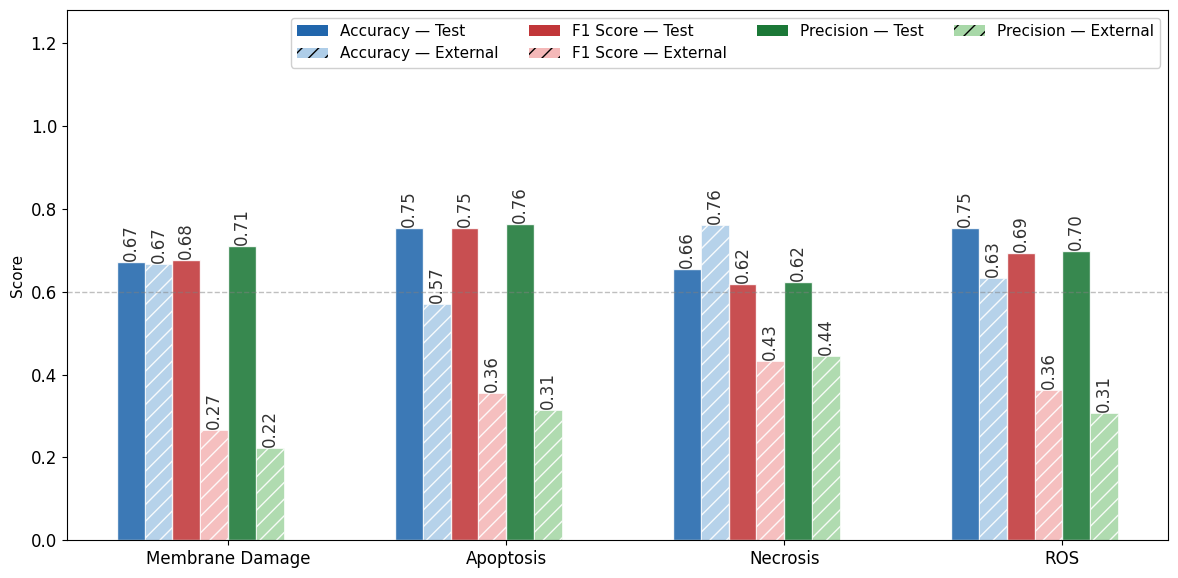

In [ ]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 6))
bio_labels = [b.replace(' (%)','').replace(' Production','') for b in BIO_COLS]
x = np.arange(len(BIO_COLS))
w = 0.10

metrics_cfg = [
    ('Accuracy',  'acc',  'acc_ex',  '#2166AC', '#AECDE8'),  # mavi tonu
    ('F1 Score',  'f1',   'f1_ex',   '#C13639', '#F4B8B8'),  # kırmızı tonu
    ('Precision', 'prec', 'prec_ex', '#1B7837', '#A8D8A8'),  # yeşil tonu
]
offsets = [-3.5*w, -2.5*w, -1.5*w, -0.5*w, 0.5*w, 1.5*w, 2.5*w, 3.5*w]

for j, (label, key_te, key_ex, col_te, col_ex) in enumerate(metrics_cfg):
    vals_te = [stage2[b].get(key_te, 0) for b in BIO_COLS]
    vals_ex = [stage2[b].get(key_ex, 0) for b in BIO_COLS]
    b1 = ax.bar(x + offsets[j*2],   vals_te, w, label=f'{label} — Test',
                color=col_te, alpha=0.88, edgecolor='white')
    b2 = ax.bar(x + offsets[j*2+1], vals_ex, w, label=f'{label} — External',
                color=col_ex, alpha=0.90, edgecolor='white',
                hatch='//', linewidth=0.5)
    for bar, val in list(zip(b1, vals_te)) + list(zip(b2, vals_ex)):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.012,
                    f'{val:.2f}', ha='center', fontsize=12,
                    rotation=90, color='#333')

ax.set_xticks(x)
ax.set_xticklabels(bio_labels, fontsize=12)
ax.set_ylim(0, 1.28)
ax.set_ylabel('Score', fontsize=11)
ax.axhline(0.6, color='gray', ls='--', lw=1, alpha=0.5)
ax.text(ax.get_xlim()[1] * 0.99, 0.615, '',
        ha='right', fontsize=11, color='gray', style='italic')


legend_elements = [
    Patch(facecolor='#2166AC', label='Accuracy — Test'),
    Patch(facecolor='#AECDE8', hatch='//', label='Accuracy — External'),
    Patch(facecolor='#C13639', label='F1 Score — Test'),
    Patch(facecolor='#F4B8B8', hatch='//', label='F1 Score — External'),
    Patch(facecolor='#1B7837', label='Precision — Test'),
    Patch(facecolor='#A8D8A8', hatch='//', label='Precision — External'),
]
ax.legend(handles=legend_elements, fontsize=11, ncol=4, loc='upper right', framealpha=0.92)
ax.grid(False)

plt.tight_layout()
plt.savefig('Fig_Stage2_Metrics.png', dpi=600, bbox_inches='tight')
plt.show()


## 5. Final Summary

In [ ]:
print('=' * 70)
print('FINAL SUMMARY')
print('=' * 70)
print(f'\nDataset: n={len(df)} | 5 NP groups | avg Pearson |r| = {avg_r:.3f}')
print(f'Label: IC50 ≤ 100 µg/mL → Toxic (ISO 10993-5:2009)')
print(f'Label changes from original: 52/304 rows (17.1%)')
print(f'\nStage 1 — Stacking (ET+GB+RF+LR → LogReg, SMOTE balanced):')
print(f'  Test Accuracy         : {test_acc:.4f}')
print(f'  Test Balanced Accuracy: {test_bacc:.4f}')
print(f'  Test AUC-ROC          : {test_auc:.4f}')
print(f'\nStage 2 — ExtraTreesRegressor + OOF TCP (10-fold CV):')
print(f'{"Endpoint":22s} {"No TCP":>7s}  {"OOF TCP":>8s} {"Δ":>6s}  {"Upper Bound":>12s}')
print('-' * 62)
for bio in BIO_COLS:
    r_no  = results[bio]['no_tcp']['Test_R2']
    r_oof = results[bio]['oof_tcp']['Test_R2']
    r_ub  = results[bio]['true_tcp']['Test_R2']
    d = r_oof - r_no; sg = '+' if d >= 0 else ''
    print(f"{bio:22s} {r_no:7.3f}  {r_oof:8.3f} {sg}{d:5.3f}  {r_ub:12.3f}")

print(f'\nKey interpretation:')
print(f'  IC50 is measured FIRST in standard workflows.')
print(f'  This framework predicts expensive downstream assays (ROS, membrane,')
print(f'  apoptosis, necrosis) from physicochemical features + IC50 toxicity class.')
print(f'  OOF ensures no data leakage. True Label TCP shows theoretical ceiling.')

# Save summary CSV
summary_rows = []
for bio in BIO_COLS:
    for tag in ['no_tcp', 'oof_tcp', 'true_tcp']:
        r = results[bio][tag]
        summary_rows.append({'Endpoint': bio, 'Version': tag,
                              'Train_R2': round(r['Train_R2'], 3),
                              'Test_R2':  round(r['Test_R2'], 3),
                              'CV_R2':    round(r['CV_R2'], 3),
                              'CV_Std':   round(r['CV_Std'], 3),
                              'RMSE':     round(r['RMSE'], 2),
                              'MAE':      round(r['MAE'], 2)})
pd.DataFrame(summary_rows).to_csv('stage2_results.csv', index=False)
lazy_df.round(4).to_csv('lazyclassifier_results.csv', index=False)
print('\nSaved: stage2_results.csv, lazyclassifier_results.csv')

FINAL SUMMARY

Dataset: n=304 | 5 NP groups | avg Pearson |r| = 0.016
Label: IC50 ≤ 100 µg/mL → Toxic (ISO 10993-5:2009)
Label changes from original: 52/304 rows (17.1%)

Stage 1 — Stacking (ET+GB+RF+LR → LogReg, SMOTE balanced):
  Test Accuracy         : 0.8689
  Test Balanced Accuracy: 0.7895
  Test AUC-ROC          : 0.9134

Stage 2 — ExtraTreesRegressor + OOF TCP (10-fold CV):
Endpoint                No TCP   OOF TCP      Δ   Upper Bound
--------------------------------------------------------------
Membrane Damage (%)      0.616     0.615 -0.001         0.737
Apoptosis (%)            0.531     0.518 -0.013         0.580
Necrosis (%)             0.541     0.543 +0.001         0.535
ROS Production           0.363     0.352 -0.010         0.580

Key interpretation:
  IC50 is measured FIRST in standard workflows.
  This framework predicts expensive downstream assays (ROS, membrane,
  apoptosis, necrosis) from physicochemical features + IC50 toxicity class.
  OOF ensures no data leakag